## makeover monday 2026-02-02

### gold prices

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('https://query.data.world/s/2aj2ed6h5yedjxwfuttxx5sv6lumte?dws=00000')
df.tail(2)

,Date,High (kg),Low (kg),Close (kg)
238,2006-06-21 0:00,21749.27,18362.89,20171.41
239,2006-05-22 0:00,21684.89,17459.47,18600.68


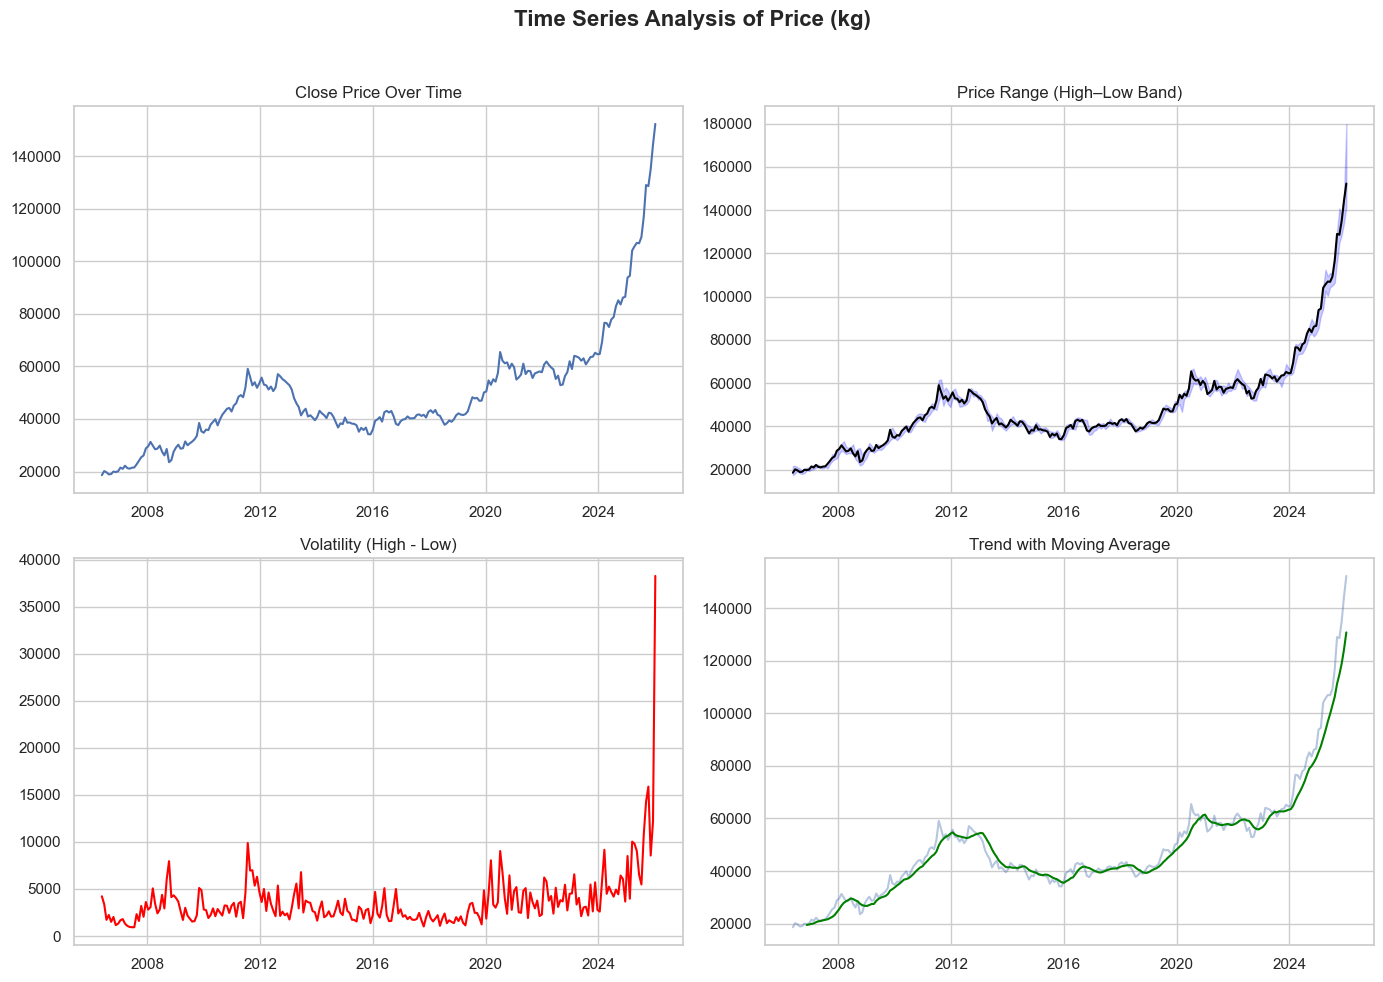

In [8]:
# Convert date
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Create derived columns
df["Range"] = df["High (kg)"] - df["Low (kg)"]
df["MA_7"] = df["Close (kg)"].rolling(7).mean()

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1Close price over time
axes[0, 0].plot(df["Date"], df["Close (kg)"], label="Close")
axes[0, 0].set_title("Close Price Over Time")

# 2. High-Low band
axes[0, 1].plot(df["Date"], df["Close (kg)"], color="black")
axes[0, 1].fill_between(
    df["Date"],
    df["Low (kg)"],
    df["High (kg)"],
    color="blue",
    alpha=0.2
)
axes[0, 1].set_title("Price Range (High–Low Band)")

# 3. Volatility (range)
axes[1, 0].plot(df["Date"], df["Range"], color="red")
axes[1, 0].set_title("Volatility (High - Low)")

# 4. Moving average
axes[1, 1].plot(df["Date"], df["Close (kg)"], alpha=0.4)
axes[1, 1].plot(df["Date"], df["MA_7"], color="green")
axes[1, 1].set_title("Trend with Moving Average")

# Master title
fig.suptitle("Time Series Analysis of Price (kg)", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()